<a href="https://colab.research.google.com/github/ved-sk/VTSP_wbc_classifier/blob/main/vtspweek2and3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#White Blood Cell classifier

## 1. Imports

In [1]:
import kagglehub
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/blood-cells")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cells' dataset.
Path to dataset files: /kaggle/input/blood-cells


In [2]:
from google.colab import drive

drive.mount('/content/drive/')


Mounted at /content/drive/


## 2. Load and explore dataset

In [3]:
import os

os.listdir('/content/drive/')

zip_path = "/content/drive/MyDrive/VTSP illumicellAI project/dataset2-master.zip"

import zipfile
import shutil
from pathlib import Path

extract_root = Path('/content/blood_cells')
local_images = extract_root / 'dataset2-master' / 'images'

if local_images.is_dir():
    print("blood_cells is already here, nothing to unzip.")
elif os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_root)
else:
    print("The Drive zip is not here, so this run will use the Kaggle download instead.")
    # build the same folder layout the later cells expect, straight from the kagglehub copy
    kaggle_images = next(p for p in Path(path).rglob('images') if (p / 'TRAIN').is_dir())
    shutil.copytree(kaggle_images, local_images)

for root, dirs, files in os.walk('/content/blood_cells'):
    print(root)

/content/blood_cells
/content/blood_cells/dataset2-master
/content/blood_cells/dataset2-master/images
/content/blood_cells/dataset2-master/images/TEST
/content/blood_cells/dataset2-master/images/TEST/EOSINOPHIL
/content/blood_cells/dataset2-master/images/TEST/NEUTROPHIL
/content/blood_cells/dataset2-master/images/TEST/LYMPHOCYTE
/content/blood_cells/dataset2-master/images/TEST/MONOCYTE
/content/blood_cells/dataset2-master/images/TEST_SIMPLE
/content/blood_cells/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL
/content/blood_cells/dataset2-master/images/TEST_SIMPLE/NEUTROPHIL
/content/blood_cells/dataset2-master/images/TEST_SIMPLE/LYMPHOCYTE
/content/blood_cells/dataset2-master/images/TEST_SIMPLE/MONOCYTE
/content/blood_cells/dataset2-master/images/TRAIN
/content/blood_cells/dataset2-master/images/TRAIN/EOSINOPHIL
/content/blood_cells/dataset2-master/images/TRAIN/NEUTROPHIL
/content/blood_cells/dataset2-master/images/TRAIN/LYMPHOCYTE
/content/blood_cells/dataset2-master/images/TRAIN/MONOCY

In [4]:
import os
from pathlib import Path

# 1. Define the path to your dataset folder
# Change this to the actual path where you extracted the Kaggle dataset
dataset_path = Path("/content/blood_cells/dataset2-master/images/TEST")

# 2. Define the target categories
categories = ["EOSINOPHIL", "LYMPHOCYTE", "MONOCYTE", "NEUTROPHIL"]

print("Counting images per category...\n")
total_count = 0

# 3. Loop through categories and count files
for category in categories:
    category_dir = dataset_path / category

    if category_dir.exists():
        # Count files with common image extensions (.jpeg, .jpg, .png)
        image_count = len([f for f in category_dir.iterdir() if f.suffix.lower() in ['.jpeg', '.jpg', '.png']])
        total_count += image_count
        print(f"Category '{category}': {image_count} images")
    else:
        print(f"Warning: Directory for '{category}' not found at {category_dir}")

print(f"\nTotal images found across all specified categories: {total_count}")


Counting images per category...

Category 'EOSINOPHIL': 623 images
Category 'LYMPHOCYTE': 620 images
Category 'MONOCYTE': 620 images
Category 'NEUTROPHIL': 624 images

Total images found across all specified categories: 2487


Week 2 Day 2 Image Exploration

Before any modeling we just look at the images: a few labeled examples, the sizes and color modes, whether any file is broken, and how much images inside one category differ. After that we make a 224 by 224 copy of the whole cache.

The Day 1 cell that unzips `dataset2-master.zip` only works if that zip sits in the mounted Drive. It isn't there in the current setup, so that cell now checks for the file first and falls back to the kagglehub download from the first cell. Either way we end up with the same `/content/blood_cells` folder.

In [5]:
import random
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

RANDOM_SEED = 42
TARGET_SIZE = (224, 224)
IMAGE_EXTENSIONS = {'.jpeg', '.jpg', '.png'}

local_dataset_dir = Path('/content/blood_cells/dataset2-master')
image_cache = local_dataset_dir / 'images'
resized_cache = local_dataset_dir / 'image_cache_224x224'
project_folder = Path('/content/drive/MyDrive/VTSP illumicellAI project')
day2_output_dir = project_folder / 'week2_day2_outputs'
day2_output_dir.mkdir(parents=True, exist_ok=True)
cache_archive = day2_output_dir / 'image_cache_224x224.zip'

# safety net in case the unzip cell above was skipped
if not image_cache.exists():
    kaggle_images = next(p for p in Path(path).rglob('images') if (p / 'TRAIN').is_dir())
    print('copying', kaggle_images, '->', image_cache)
    shutil.copytree(kaggle_images, image_cache)

source_images = sorted(p for p in image_cache.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)
splits = sorted({p.parent.parent.name for p in source_images})
categories = sorted({p.parent.name for p in source_images})

print('image source:', image_cache)
print('total image files:', len(source_images))
print('split folders inside the cache:', splits)
print('categories:', categories)
print('example relative paths:', [str(p.relative_to(image_cache)) for p in source_images[:2]])

counts_table = pd.crosstab(
    pd.Series([p.parent.parent.name for p in source_images], name='split'),
    pd.Series([p.parent.name for p in source_images], name='category'),
)
print()
print(counts_table.to_string())
print()
print('images per category across all splits:')
for category, count in sorted(Counter(p.parent.name for p in source_images).items()):
    print(' ', category, count)


image source: /content/blood_cells/dataset2-master/images
total image files: 12515
split folders inside the cache: ['TEST', 'TEST_SIMPLE', 'TRAIN']
categories: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
example relative paths: ['TEST/EOSINOPHIL/_0_1616.jpeg', 'TEST/EOSINOPHIL/_0_1794.jpeg']

category     EOSINOPHIL  LYMPHOCYTE  MONOCYTE  NEUTROPHIL
split                                                    
TEST                623         620       620         624
TEST_SIMPLE          13           6         4          48
TRAIN              2497        2483      2478        2499

images per category across all splits:
  EOSINOPHIL 3133
  LYMPHOCYTE 3109
  MONOCYTE 3102
  NEUTROPHIL 3171


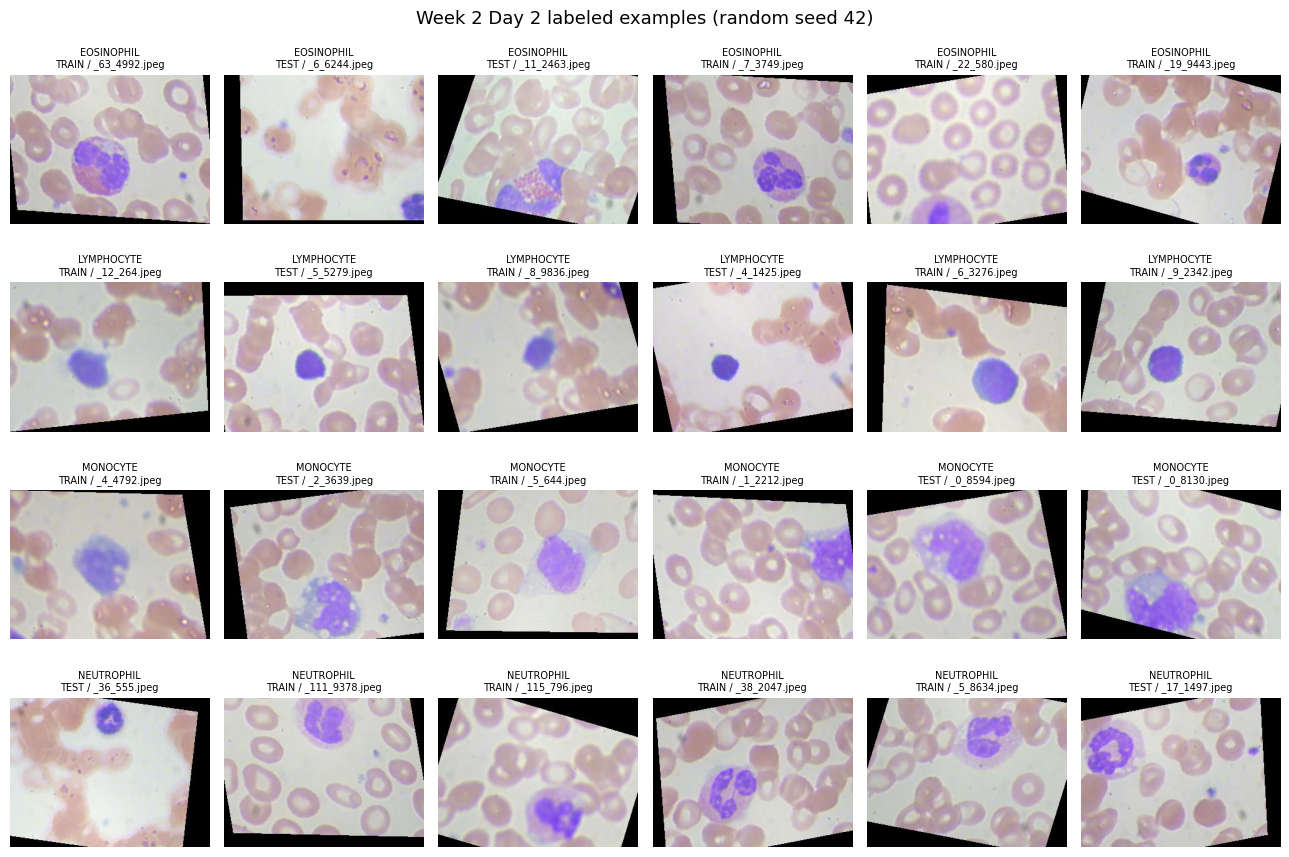

saved grid to /content/drive/MyDrive/VTSP illumicellAI project/week2_day2_outputs/day2_labeled_examples.png


In [6]:
random.seed(RANDOM_SEED)
examples_per_category = 6

paths_by_category = {category: [p for p in source_images if p.parent.name == category] for category in categories}
sampled_examples = {category: random.sample(paths_by_category[category], examples_per_category) for category in categories}

fig, axes = plt.subplots(len(categories), examples_per_category, figsize=(13, 9))
for row, category in enumerate(categories):
    for column, image_path in enumerate(sampled_examples[category]):
        with Image.open(image_path) as im:
            axes[row, column].imshow(im.convert('RGB'))
        axes[row, column].set_title(category + '\n' + image_path.parent.parent.name + ' / ' + image_path.name, fontsize=7)
        axes[row, column].axis('off')

fig.suptitle('Week 2 Day 2 labeled examples (random seed ' + str(RANDOM_SEED) + ')', fontsize=13)
fig.tight_layout()
grid_path = day2_output_dir / 'day2_labeled_examples.png'
fig.savefig(grid_path, dpi=110)
plt.show()
print('saved grid to', grid_path)


In [7]:
inventory_rows = []
for image_path in tqdm(source_images, desc='reading images'):
    row = {
        'relative_path': str(image_path.relative_to(image_cache)),
        'split': image_path.parent.parent.name,
        'category': image_path.parent.name,
        'width': None,
        'height': None,
        'mode': None,
        'format': None,
        'readable': False,
        'error': '',
    }
    try:
        with Image.open(image_path) as im:
            im.load()
            row.update(width=im.width, height=im.height, mode=im.mode, format=im.format, readable=True)
    except Exception as error:
        row['error'] = type(error).__name__ + ': ' + str(error)
    inventory_rows.append(row)

image_inventory = pd.DataFrame(inventory_rows)
valid_inventory = image_inventory[image_inventory['readable']]

print('images checked:', len(image_inventory))
print('readable:', len(valid_inventory))
print('unreadable:', len(image_inventory) - len(valid_inventory))
print()
print('sizes found (width x height):')
print(valid_inventory.groupby(['width', 'height']).size().to_string())
print()
print('color modes found:')
print(valid_inventory['mode'].value_counts().to_string())
print()
print('file formats found:')
print(valid_inventory['format'].value_counts().to_string())

inventory_csv = day2_output_dir / 'day2_image_inventory.csv'
image_inventory.to_csv(inventory_csv, index=False)
print()
print('saved inventory to', inventory_csv)

unreadable_inventory = image_inventory[~image_inventory['readable']]
if len(unreadable_inventory):
    unreadable_csv = day2_output_dir / 'day2_unreadable_images.csv'
    unreadable_inventory.to_csv(unreadable_csv, index=False)
    print('saved', len(unreadable_inventory), 'unreadable files to', unreadable_csv)
    print(unreadable_inventory[['relative_path', 'error']].to_string(index=False))
else:
    print('no unreadable files, so day2_unreadable_images.csv was not created')


reading images:   0%|          | 0/12515 [00:00<?, ?it/s]

images checked: 12515
readable: 12515
unreadable: 0

sizes found (width x height):
width  height
320    240       12515

color modes found:
mode
RGB    12515

file formats found:
format
JPEG    12515

saved inventory to /content/drive/MyDrive/VTSP illumicellAI project/week2_day2_outputs/day2_image_inventory.csv
no unreadable files, so day2_unreadable_images.csv was not created


## 3. Resizing and preprocessing

What the scan shoows?

All 12,515 images opened fine, making sure nothing was skipped and there was no broken file list to write.

The four categories are close in size: eosinophil 3,133, lymphocyte 3,109, monocyte 3,102, neutrophil 3,171. They sit in three split folders, TRAIN 9,957, TEST 2,487 and TEST_SIMPLE 71. TEST_SIMPLE is very small and uneven (13 / 6 / 4 / 48), so it isn't much use for comparing categories.

Every source file is 320x240 RGB JPEG. One size, color mode, and format. We still resize, because 224x224 is the input size we picked for the project. Going from 320x240 to 224x224 changes the original proportions a litttle, and every image gets the same change.

In the grid, lymphocytes and monocytes can look similar, both showing one round purple nucleus, and a tightly cropped monocyte can look close to a lymphocyte. Eosinophils and neutrophils can also be hard to separate, since both have lobed nuclei and the granule color is the main visible clue. This is only what a few examples look like, so it's worth checking on more images before we treat it as settled.

Inside one category there's a lot of variation. Many images look rotated, which leaves black wedges in the corners, backgrounds run from near white to greenish to pink, brightness and focus vary, the cell is sometimes centered and sometimes near an edge, and a few frames have two cells.

A few examples worth a second look: TEST/EOSINOPHIL/_6_6244.jpeg has no clear white cell, TRAIN/EOSINOPHIL/_22_580.jpeg is cut by the bottom edge, and TEST/NEUTROPHIL/_36_555.jpeg sits in a corner on a darker background. We didn't delete anything and we're not calling any label wrong, they're just in the inventory CSV if someone wants to look.


In [8]:
def archive_is_complete(archive_path, expected_names):
    if not archive_path.exists():
        return False
    try:
        with zipfile.ZipFile(archive_path) as archive:
            names = {name for name in archive.namelist() if not name.endswith('/')}
    except zipfile.BadZipFile:
        return False
    return names == expected_names


expected_cache_names = {p.relative_to(image_cache).as_posix() for p in source_images}

# a fresh runtime starts with no cache, so unpack the Drive zip instead of resizing everything again
if not resized_cache.exists() and archive_is_complete(cache_archive, expected_cache_names):
    print('restoring the resized cache from', cache_archive)
    with zipfile.ZipFile(cache_archive) as archive:
        archive.extractall(resized_cache)

resample_filter = Image.Resampling.LANCZOS if hasattr(Image, 'Resampling') else Image.LANCZOS
resized_cache.mkdir(parents=True, exist_ok=True)

manifest_rows = []
resized_count = 0
skipped_count = 0
failed_count = 0

for image_path in tqdm(source_images, desc='resizing to 224x224'):
    relative_path = image_path.relative_to(image_cache)
    destination = resized_cache / relative_path
    row = {
        'source_relative_path': str(relative_path),
        'destination_relative_path': str(relative_path),
        'category': image_path.parent.name,
        'original_width': None,
        'original_height': None,
        'final_width': None,
        'final_height': None,
        'status': '',
        'error': '',
    }
    try:
        with Image.open(image_path) as source_image:
            row['original_width'], row['original_height'] = source_image.size

            existing_size = None
            if destination.exists():
                try:
                    with Image.open(destination) as existing_image:
                        existing_image.load()
                        existing_size = existing_image.size
                except Exception:
                    existing_size = None

            if existing_size == TARGET_SIZE:
                row['final_width'], row['final_height'] = existing_size
                row['status'] = 'skipped'
                skipped_count += 1
            else:
                # rebuild the file if the old copy is missing, broken or the wrong size
                destination.parent.mkdir(parents=True, exist_ok=True)
                resized_image = source_image.convert('RGB').resize(TARGET_SIZE, resample_filter)
                resized_image.save(destination, format='JPEG', quality=95)
                row['final_width'], row['final_height'] = resized_image.size
                row['status'] = 'resized'
                resized_count += 1
    except Exception as error:
        row['status'] = 'failed'
        row['error'] = type(error).__name__ + ': ' + str(error)
        failed_count += 1
    manifest_rows.append(row)

resize_manifest = pd.DataFrame(manifest_rows)
manifest_csv = day2_output_dir / 'day2_resize_224x224.csv'
resize_manifest.to_csv(manifest_csv, index=False)

processed = resize_manifest[resize_manifest['status'].isin(['resized', 'skipped'])]
all_are_target = bool(((processed['final_width'] == 224) & (processed['final_height'] == 224)).all())

print('source images found:', len(source_images))
print('resized in this run:', resized_count)
print('already 224x224 and skipped:', skipped_count)
print('failed:', failed_count)
print('destination cache:', resized_cache)
print('every processed output is 224 x 224:', all_are_target)
print('manifest saved to:', manifest_csv)
print()
print('files per category in the resized cache:')
for category, count in sorted(Counter(p.parent.name for p in resized_cache.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS).items()):
    print(' ', category, count)


restoring the resized cache from /content/drive/MyDrive/VTSP illumicellAI project/week2_day2_outputs/image_cache_224x224.zip


resizing to 224x224:   0%|          | 0/12515 [00:00<?, ?it/s]

source images found: 12515
resized in this run: 0
already 224x224 and skipped: 12515
failed: 0
destination cache: /content/blood_cells/dataset2-master/image_cache_224x224
every processed output is 224 x 224: True
manifest saved to: /content/drive/MyDrive/VTSP illumicellAI project/week2_day2_outputs/day2_resize_224x224.csv

files per category in the resized cache:
  EOSINOPHIL 3133
  LYMPHOCYTE 3109
  MONOCYTE 3102
  NEUTROPHIL 3171


checking resized cache:   0%|          | 0/12515 [00:00<?, ?it/s]

files in the resized cache: 12515
reopened successfully: 12515
exactly 224 x 224: 12515
category counts match the processed sources: True
nested copies of the cache inside itself: 0
resized cache is outside the source cache: True


rechecking the originals:   0%|          | 0/12515 [00:00<?, ?it/s]

original files still present: 12515 of 12515
original sizes now: {(320, 240): 12515}


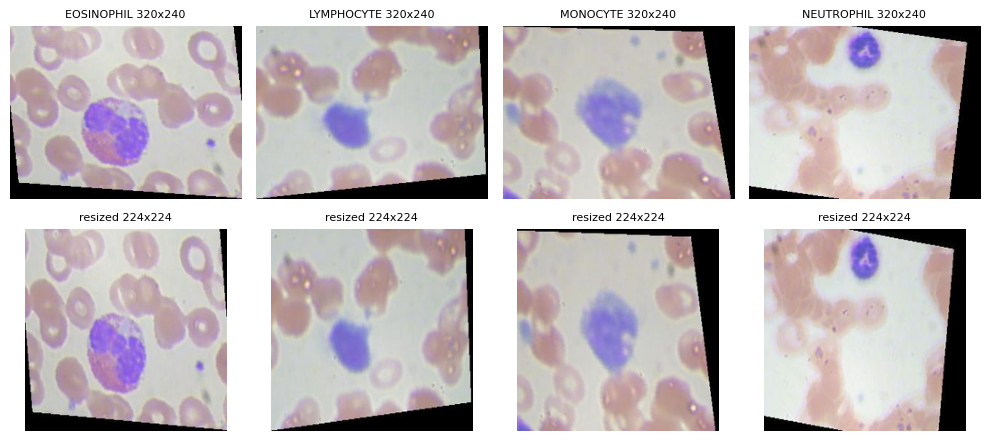

Drive zip already matches the cache, reusing /content/drive/MyDrive/VTSP illumicellAI project/week2_day2_outputs/image_cache_224x224.zip


In [9]:
output_images = sorted(p for p in resized_cache.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)

check_rows = []
for output_path in tqdm(output_images, desc='checking resized cache'):
    row = {'relative_path': str(output_path.relative_to(resized_cache)), 'category': output_path.parent.name,
           'width': None, 'height': None, 'readable': False}
    try:
        with Image.open(output_path) as im:
            im.load()
            row.update(width=im.width, height=im.height, readable=True)
    except Exception:
        pass
    check_rows.append(row)

output_check = pd.DataFrame(check_rows)
correct_size = (output_check['width'] == 224) & (output_check['height'] == 224)

print('files in the resized cache:', len(output_check))
print('reopened successfully:', int(output_check['readable'].sum()))
print('exactly 224 x 224:', int(correct_size.sum()))
print('category counts match the processed sources:',
      output_check['category'].value_counts().to_dict() == processed['category'].value_counts().to_dict())
print('nested copies of the cache inside itself:',
      len([p for p in resized_cache.rglob('*') if p.is_dir() and p.name == resized_cache.name]))
print('resized cache is outside the source cache:', image_cache not in resized_cache.parents)

source_images_now = sorted(p for p in image_cache.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)
source_sizes_now = Counter()
for source_path in tqdm(source_images_now, desc='rechecking the originals'):
    with Image.open(source_path) as im:
        source_sizes_now[im.size] += 1
print('original files still present:', len(source_images_now), 'of', len(source_images))
print('original sizes now:', dict(source_sizes_now))

comparison_paths = [sampled_examples[category][0] for category in categories]
fig, axes = plt.subplots(2, len(comparison_paths), figsize=(10, 4.5))
for column, source_path in enumerate(comparison_paths):
    relative_path = source_path.relative_to(image_cache)
    with Image.open(source_path) as im:
        axes[0, column].imshow(im.convert('RGB'))
    with Image.open(resized_cache / relative_path) as im:
        axes[1, column].imshow(im)
    axes[0, column].set_title(source_path.parent.name + ' 320x240', fontsize=8)
    axes[1, column].set_title('resized 224x224', fontsize=8)
    axes[0, column].axis('off')
    axes[1, column].axis('off')
fig.tight_layout()
plt.show()

cache_is_good = (
    len(output_check) == len(processed)
    and bool(output_check['readable'].all())
    and bool(correct_size.all())
)

if not cache_is_good:
    print('the cache did not pass the check, leaving the Drive zip alone')
elif archive_is_complete(cache_archive, expected_cache_names):
    print('Drive zip already matches the cache, reusing', cache_archive)
else:
    # zip locally first, writing thousands of small entries straight into Drive is slow
    staging_archive = Path('/content/image_cache_224x224.zip')
    with zipfile.ZipFile(staging_archive, 'w', zipfile.ZIP_DEFLATED) as archive:
        for output_path in tqdm(output_images, desc='zipping the resized cache'):
            archive.write(output_path, output_path.relative_to(resized_cache).as_posix())
    shutil.copy(staging_archive, cache_archive)
    staging_archive.unlink()
    print('wrote', cache_archive)


Our next step here is to make sure each label is encoded, spot-check everything, and make sensible train-test splits to adequately train our data.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

categories = ["EOSINOPHIL", "LYMPHOCYTE", "MONOCYTE", "NEUTROPHIL"]
dataset_path = Path("/content/blood_cells/dataset2-master/images/TEST")

label_mapping = {
    "EOSINOPHIL": 0,
    "LYMPHOCYTE": 1,
    "MONOCYTE": 2,
    "NEUTROPHIL": 3
}

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(dataset_path, category)

    for filename in os.listdir(category_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(
                os.path.join(category_path, filename)
            )
            labels.append(label_mapping[category])

data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})


data.head()


,image_path,label
0,/content/blood_cells/dataset2-master/images/TE...,0
1,/content/blood_cells/dataset2-master/images/TE...,0
2,/content/blood_cells/dataset2-master/images/TE...,0
3,/content/blood_cells/dataset2-master/images/TE...,0
4,/content/blood_cells/dataset2-master/images/TE...,0


In [11]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    data,
    test_size = 0.20,
    random_state = 50,
    stratify = data["label"],
)

In [12]:
print("Training set:")
print(train_data["label"].value_counts().sort_index())

print("\nTest set:")
print(test_data["label"].value_counts().sort_index())



Training set:
label
0    498
1    496
2    496
3    499
Name: count, dtype: int64

Test set:
label
0    125
1    124
2    124
3    125
Name: count, dtype: int64


In [13]:
train_paths = set(train_data["image_path"])
test_paths = set(test_data["image_path"])

overlap = train_paths.intersection(test_paths)

print("Number of overlapping images:", len(overlap))

Number of overlapping images: 0


In [14]:
import json

with open("/content/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)


train_data.to_csv("/content/train_split.csv", index=False)
test_data.to_csv("/content/test_split.csv", index=False)


train_data = pd.read_csv("/content/train_split.csv")
test_data = pd.read_csv("/content/test_split.csv")

## 4. Building and training data

#Week 3: Training the data

### We'll be using a basic MobileNetV2 transfer learning model to help train our data. We do this by importing it from TensorFlow.

In [15]:
import tensorflow as tf
import numpy as np
import time
import PIL.Image as Image
import matplotlib.pylab as plt
import tensorflow_hub as hub
import datetime
import os

%load_ext tensorboard

test_dir = "/content/blood_cells/dataset2-master/images/TEST"
test_simple_dir = "/content/blood_cells/dataset2-master/images/TEST_SIMPLE"
train_dir = "/content/blood_cells/dataset2-master/images/TRAIN"

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

print(os.listdir(train_dir))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
['EOSINOPHIL', 'NEUTROPHIL', 'LYMPHOCYTE', 'MONOCYTE']


In [16]:
IMAGE_SIZE = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMAGE_SIZE,
    batch_size = batch_size,
    shuffle=True,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size = batch_size,
    shuffle=False,
)

Found 9957 files belonging to 4 classes.
Found 2487 files belonging to 4 classes.


In [17]:
print(train_dataset.class_names)

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [18]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(4)
])

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=3
)

model.evaluate(test_dataset)

Epoch 1/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6056 - loss: 0.9638
Epoch 2/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7512 - loss: 0.6702
Epoch 3/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7998 - loss: 0.5586
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.5207 - loss: 1.1980


[1.1980066299438477, 0.5207076668739319]

Starting accuracy as of 7/30/2026 at 2:22 PM PST

*   Epoch 1: 312/312, accuracy: 0.6290, loss: 0.9227
*   Epoch 2: 312/312, accuracy: 0.7596, loss: 0.6542
*   Epoch 3: 312/312, accuracy: 0.7993, loss: 0.5515
  * 78/78, accuracy: 0.5219, loss: 1.2296







Here, we'll test some images to make sure the model is working fine.

Here, we'll make a confusion matrix for all four classes to visualize the results.

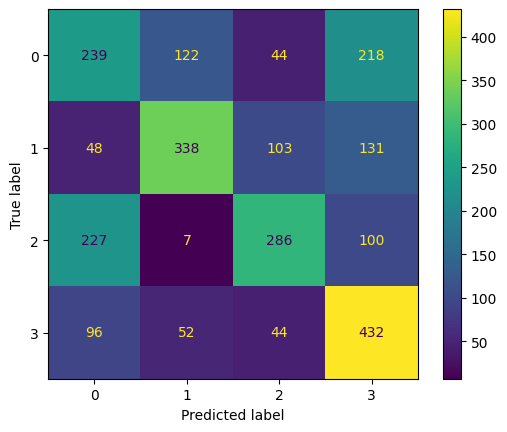

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm,
   #                   display_labels=label_mapping)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                      )
disp.plot()
plt.show()



As seen in this matrix, the numbers 213, 240, 145, and 135 are the biggest outliers here. This signifies that the biggest culprits harming the accuracy score are, in order: eosonophil incorrectly predicted as a neutrophil, monocyte incorrectly predicted as an eosinophil, lymphocyte incorrectly predicted as a neutrophil, and eosinophil incorrectly predicted as a lymphocyte.

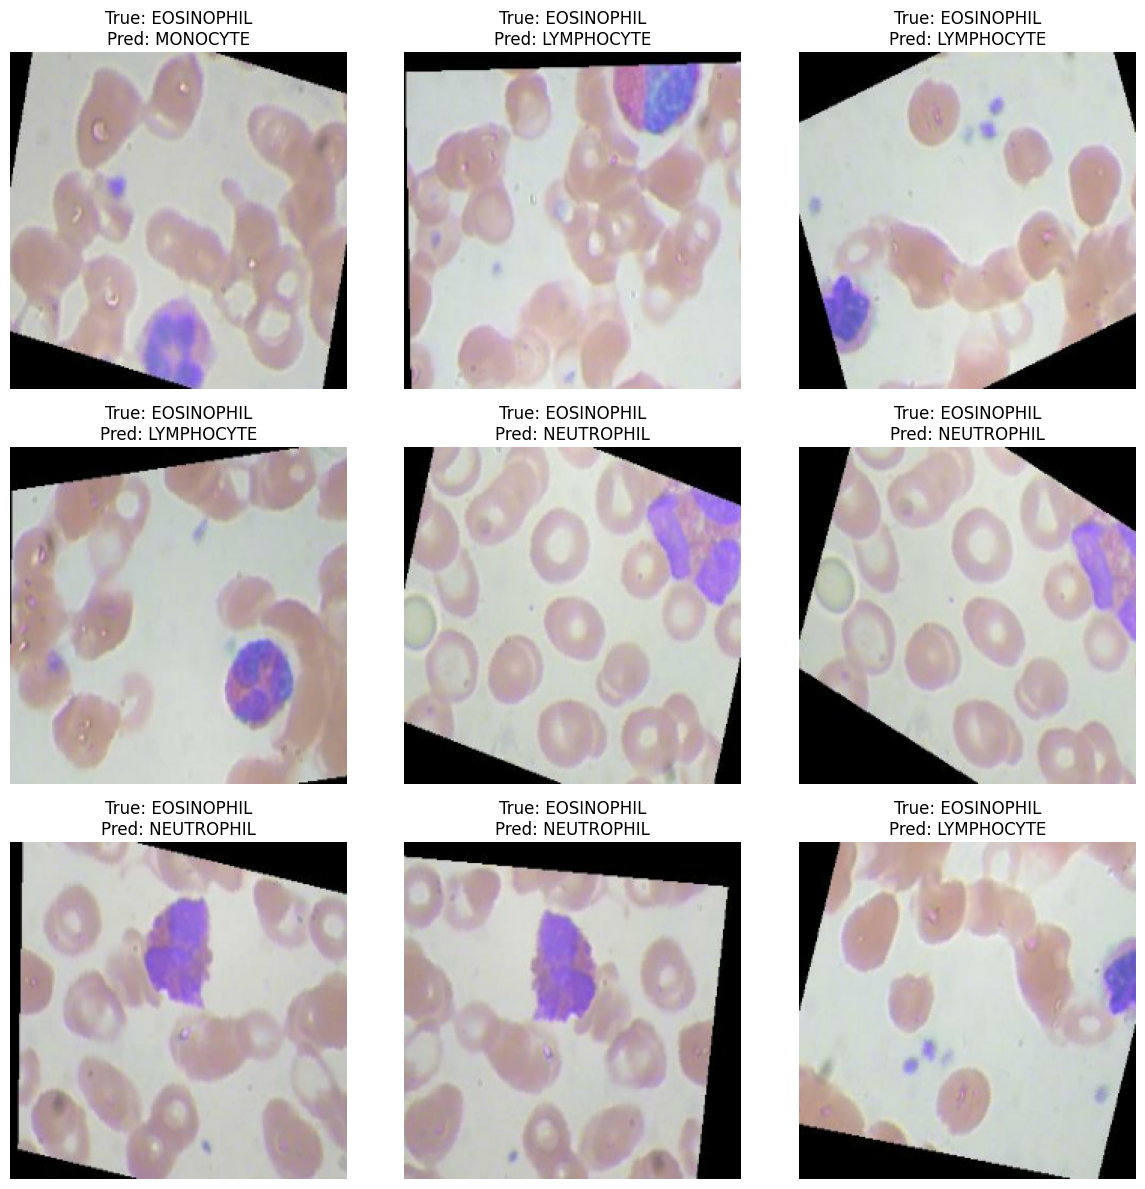

In [21]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_dataset.class_names

wrong_images = []
wrong_true = []
wrong_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(len(labels)):
        if predicted_labels[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_true.append(labels[i].numpy())
            wrong_pred.append(predicted_labels[i])

plt.figure(figsize=(12,12))

for i in range(min(9, len(wrong_images))):
    plt.subplot(3,3,i+1)

    plt.imshow(wrong_images[i].astype("uint8"))

    plt.title(
        f"True: {class_names[wrong_true[i]]}\n"
        f"Pred: {class_names[wrong_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Cleaning up and retesting the data

In [22]:
'''tf.keras.applications.mobilenet_v2.preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(4)
])

#base_model = tf.keras.applications.MobileNetV2(
    #input_shape=(224, 224, 3),
    #include_top=False,
    #weights='imagenet'
#)
#base_model.trainable = True


model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=3
)

model.evaluate(test_dataset)'''


'tf.keras.applications.mobilenet_v2.preprocess_input\n\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),\n    tf.keras.layers.RandomRotation(0.1),\n    tf.keras.layers.RandomZoom(0.1),\n])\n\nmodel = tf.keras.Sequential([\n    tf.keras.layers.Lambda(\n    tf.keras.applications.mobilenet_v2.preprocess_input\n),\n    base_model,\n    tf.keras.layers.GlobalAveragePooling2D(),\n    tf.keras.layers.Dense(4)\n])\n\n#base_model = tf.keras.applications.MobileNetV2(\n    #input_shape=(224, 224, 3),\n    #include_top=False,\n    #weights=\'imagenet\'\n#)\n#base_model.trainable = True\n\n\nmodel.compile(\n    optimizer="adam",\n    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    train_dataset,\n    epochs=3\n)\n\nmodel.evaluate(test_dataset)'

Starting accuracy as of 08/03/2026 at 3:00 PM PST

*   Change: tf.keras.layers.Rescaling(1./255) was altered to tf.keras.applications.mobilenet_v2.preprocess_input and the model was slightly altered
*   Epoch 1: 312/312, accuracy: 0.6102, loss: 0.9421
*   Epoch 2: 312/312, accuracy: 0.7650, loss: 0.6436
*   Epoch 3: 312/312, accuracy: 0.8084, loss: 0.5356
  * 78/78, accuracy: 0.5480, loss: 1.1559

 The data here suggests overfitting, where the dataset is remains mostly accurate for training, but it can't account for the separate testing dataset with unseen images. Evidenced by how the accuracies for the three epochs were relatively similar yet the testing accuracy only marginally improved.

In [23]:
'''tf.keras.applications.mobilenet_v2.preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(4)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True


model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=3
)

model.evaluate(test_dataset)'''


'tf.keras.applications.mobilenet_v2.preprocess_input\n\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),\n    tf.keras.layers.RandomRotation(0.1),\n    tf.keras.layers.RandomZoom(0.1),\n])\n\nmodel = tf.keras.Sequential([\n    tf.keras.layers.Lambda(\n    tf.keras.applications.mobilenet_v2.preprocess_input\n),\n    base_model,\n    tf.keras.layers.GlobalAveragePooling2D(),\n    tf.keras.layers.Dense(4)\n])\n\nbase_model = tf.keras.applications.MobileNetV2(\n    input_shape=(224, 224, 3),\n    include_top=False,\n    weights=\'imagenet\'\n)\nbase_model.trainable = True\n\n\nmodel.compile(\n    optimizer="adam",\n    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    train_dataset,\n    epochs=3\n)\n\nmodel.evaluate(test_dataset)'

In [24]:
'''from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm,
   #                   display_labels=label_mapping)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                      )
disp.plot()
plt.show()'''

'from sklearn.datasets import make_classification\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\n#import numpy as np\n\ny_true = []\ny_pred = []\n\nfor images, labels in test_dataset:\n    predictions = model.predict(images, verbose=0)\n    predicted_labels = np.argmax(predictions, axis=1)\n\n    y_true.extend(labels.numpy())\n    y_pred.extend(predicted_labels)\n\n#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)\n#disp = ConfusionMatrixDisplay(confusion_matrix=cm,\n   #                   display_labels=label_mapping)\n\ncm = confusion_matrix(y_true, y_pred)\n\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm,\n                      )\ndisp.plot()\nplt.show()'

As seen in this matrix, the numbers 240, 223, 188, and 112 are the biggest outliers here. This signifies that the biggest culprits harming the accuracy score are, in order: neutrophil incorrectly predicted as a eosonophil, monocyte incorrectly predicted as an eosinophil, lymphocyte incorrectly predicted as a eosonophil, and eosinophil incorrectly predicted as a neutrophil.


In [25]:
'''tf.keras.applications.mobilenet_v2.preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(4)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    )
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=5
)

model.evaluate(test_dataset)'''

'tf.keras.applications.mobilenet_v2.preprocess_input\n\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),\n    tf.keras.layers.RandomRotation(0.1),\n    tf.keras.layers.RandomZoom(0.1),\n])\n\nmodel = tf.keras.Sequential([\n    tf.keras.layers.Lambda(\n    tf.keras.applications.mobilenet_v2.preprocess_input\n),\n    base_model,\n    tf.keras.layers.GlobalAveragePooling2D(),\n    tf.keras.layers.Dense(4)\n])\n\nbase_model = tf.keras.applications.MobileNetV2(\n    input_shape=(224, 224, 3),\n    include_top=False,\n    )\nbase_model.trainable = True\n\nfor layer in base_model.layers[:-20]:\n    layer.trainable = False\n\n\nmodel.compile(\n    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),\n    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    train_dataset,\n    epochs=5\n)\n\nmodel.evaluate(test_dataset)'

Starting accuracy as of 8/03/2026 at 3:51 PM PST

* Epoch 1: 312/312, accuracy: 0.5496, loss: 1.1158
* Epoch 2: 312/312, accuracy: 0.7907, loss: 0.6294
* Epoch 3: 312/312, accuracy: 0.8738, loss: 0.4156
* Epoch 4: 312/312, accuracy: 0.9132, loss: 0.2992
* Epoch 5: 312/312, accuracy: 0.9422, loss: 0.2182

78/78, accuracy: 0.5967, loss: 1.2247

In [26]:
'''from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm,
   #                   display_labels=label_mapping)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                      )
disp.plot()
plt.show()'''

'from sklearn.datasets import make_classification\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\n#import numpy as np\n\ny_true = []\ny_pred = []\n\nfor images, labels in test_dataset:\n    predictions = model.predict(images, verbose=0)\n    predicted_labels = np.argmax(predictions, axis=1)\n\n    y_true.extend(labels.numpy())\n    y_pred.extend(predicted_labels)\n\n#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)\n#disp = ConfusionMatrixDisplay(confusion_matrix=cm,\n   #                   display_labels=label_mapping)\n\ncm = confusion_matrix(y_true, y_pred)\n\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm,\n                      )\ndisp.plot()\nplt.show()'

Test - Fix: monocyte predicted as eosonophil, neutrophil predicted as eosonopil. and esonophil predicted as lymphocyte

Train - Fix: neutrophil predicted as eosonophil or lymphocyte

In [27]:
'''tf.keras.applications.mobilenet_v2.preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    )
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=5
)

model.evaluate(test_dataset)'''

'tf.keras.applications.mobilenet_v2.preprocess_input\n\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),\n    tf.keras.layers.RandomRotation(0.1),\n    tf.keras.layers.RandomZoom(0.1),\n])\n\nmodel = tf.keras.Sequential([\n    tf.keras.layers.Lambda(\n    tf.keras.applications.mobilenet_v2.preprocess_input\n),\n    base_model,\n    tf.keras.layers.GlobalAveragePooling2D(),\n    tf.keras.layers.Dropout(0.3),\n    tf.keras.layers.Dense(4)\n])\n\nbase_model = tf.keras.applications.MobileNetV2(\n    input_shape=(224, 224, 3),\n    include_top=False,\n    )\nbase_model.trainable = True\n\nfor layer in base_model.layers[:-20]:\n    layer.trainable = False\n\n\nmodel.compile(\n    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),\n    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    train_dataset,\n    epochs=5\n)\n\nmodel.evaluate(test_dataset)'

In [28]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
batch_size = 32
seed = 50  # Must be identical for both calls to prevent data leakage

# 1. Training Dataset (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.20,
    subset="training",
    seed=seed
)

# 2. Validation Dataset (20%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.20,
    subset="validation",
    seed=seed
)

Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.


In [32]:
tf.keras.applications.mobilenet_v2.preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau as reduce_lr


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1,0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    )
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

ReduceLROnPlateau = reduce_lr

validation_data=val_dataset
callbacks=[early_stop]

model.save("/content/modern_streamlit_model.keras")

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=[
      early_stop,
      reduce_lr()
    ]
)

model.evaluate(test_dataset)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 66s 178ms/step - accuracy: 0.4399 - loss: 1.2446 - val_accuracy: 0.3310 - val_loss: 1.7620 - learning_rate: 1.0000e-05
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.6790 - loss: 0.8329 - val_accuracy: 0.3621 - val_loss: 1.6267 - learning_rate: 1.0000e-05
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.7748 - loss: 0.6142 - val_accuracy: 0.4545 - val_loss: 1.3197 - learning_rate: 1.0000e-05
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.8397 - loss: 0.4646 - val_accuracy: 0.5791 - val_loss: 0.9893 - learning_rate: 1.0000e-05
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8784 - loss: 0.3656 - val_accuracy: 0.7127 - val_loss: 0.7327 - learning_rate: 1.0000e-05
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.5078 - loss: 1.4158


[1.4157917499542236, 0.5078407526016235]

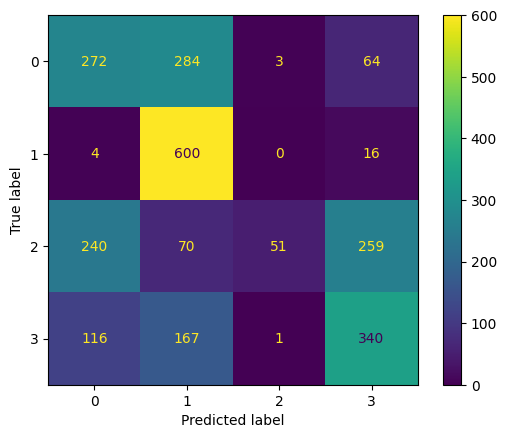

In [33]:
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

#cm = confusion_matrix(y_true, y_pred, labels=label_mapping)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm,
   #                   display_labels=label_mapping)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                      )
disp.plot()
plt.show()

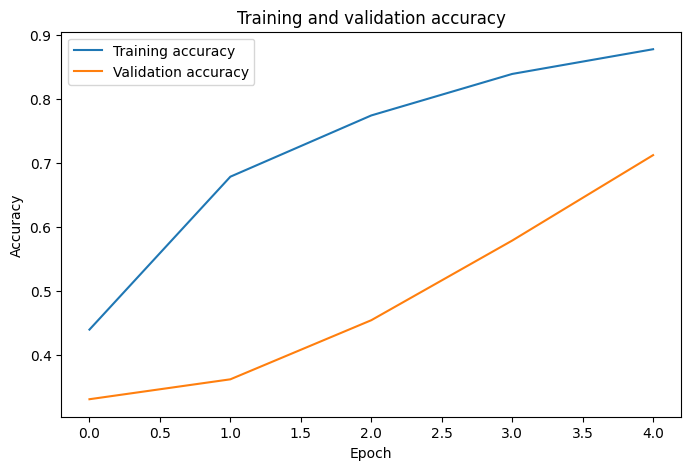

In [34]:
history_mobilenetv2 = history

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_mobilenetv2.history['accuracy'], label='Training accuracy')
plt.plot(history_mobilenetv2.history['val_accuracy'], label='Validation accuracy')

plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

It's probably the end of the road for MobileNetV2. We'd have to do a lot of coding just to squeeze out just a few more percentage points of test accuracy. So 65% is the right place to stop and move on to building our Streamlit application.

## With this, we now need to build a Streamlit application.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 125.9 MB/s eta 0:00:00


In [37]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
    tf.keras.applications.mobilenet_v2.preprocess_input
),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4)
])

streamlit_model = model

model.save("streamlit_model.keras")

class_names = [
    "EOSINOPHIL",
    "LYMPHOCYTE",
    "MONOCYTE",
    "NEUTROPHIL"
]



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [38]:
uploaded_file = st.file_uploader(
    "Upload a white blood cell image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    # Load image
    image = Image.open(uploaded_file).convert("RGB")

    # Display original image
    st.image(image, caption="Uploaded image")

    # Preprocess image
    image = image.resize((224, 224))
    image_array = np.array(image)
    image_array = np.expand_dims(image_array, axis=0)

    # MobileNetV2 preprocessing
    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    # Predict only when button is clicked
    if st.button("Predict"):

        prediction = model.predict(image_array)

        predicted_class = class_names[np.argmax(prediction)]

        st.success(f"Prediction: {predicted_class}")


2026-08-10 23:02:11.046 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 23:02:11.052 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 23:02:11.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 23:02:12.020 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-10 23:02:12.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-10 23:02:12.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [39]:
import os
import sys

# Check if running in Google Colab
try:
    from google.colab import drive, userdata
    COLAB = True
    print("Note: Using Google Colab")

    # Mount Google Drive for file access
    drive.mount('/content/drive')

    # Securely set environment variables using Colab Secrets
    # Note: Make sure you named your secret "OPENAI_API_KEY" in the Colab UI
    os.environ["openai_key"] = userdata.get('openai_key')

except ImportError:
    COLAB = False
    print("Note: Not using Google Colab. Ensure openai_key is set in your environment.")

if COLAB:
    !pip install -q langchain langchain-openai openai streamlit


Note: Using Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 21.7 MB/s eta 0:00:00


In [40]:
#model.predict(image_array)
print(class_names)

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [41]:
'''%%writefile app.py
import streamlit as st

st.write("Yellow")'''

'%%writefile app.py\nimport streamlit as st\n\nst.write("Yellow")'

In [42]:
#!curl https://loca.lt/mytunnelpassword

In [43]:
#!streamlit run app.py &>/content/logs.txt &

In [44]:
#!npx localtunnel --port 8501

In [50]:
%%writefile app.py
import os
import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

# ---------------------------------------------------------
# 1. PAGE SETUP & CONFIGURATION (Day 5)
# ---------------------------------------------------------
st.set_page_config(page_title="WBC Classifier", layout="centered")

st.title("TensorFlow WBC Classifier")
st.markdown("Upload a blood smear image to identify white blood cell categories and assess certainty.")

CLASS_NAMES = ["Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]
CONFIDENCE_THRESHOLD = 0.75  # Day 4: Below 75% triggers human review requirement

# ---------------------------------------------------------
# 2. CUSTOM LAYER REGISTRATION & MODEL LOADING (Day 2)
# ---------------------------------------------------------
def preprocess_input(x):
    return x

try:
    tf.keras.utils.register_keras_serializable(package="Custom", name="preprocess_input")(preprocess_input)
except AttributeError:
    pass

MODEL_PATH = "modern_streamlit_model.keras"

@st.cache_resource
def load_my_model(model_path):
    if os.path.exists(model_path):
        try:
            custom_dict = {
                "preprocess_input": preprocess_input,
                "function": preprocess_input
            }
            model = tf.keras.models.load_model(
                model_path,
                compile=False,
                custom_objects=custom_dict
            )
            return model, "success"
        except Exception as e:
            # Fallback model with 4 output classes matching WBC types
            fallback = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(224, 224, 3)),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(4, activation='softmax')
            ])
            return fallback, f"error: {str(e)}"
    else:
        fallback = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(224, 224, 3)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(4, activation='softmax')
        ])
        return fallback, "warning"

model, status = load_my_model(MODEL_PATH)

if "success" in status:
    st.sidebar.success("✅ Model loaded successfully!")
elif "error" in status:
    st.sidebar.error(f"🛑 Error reading model: {status}")
else:
    st.sidebar.warning(f"⚠️ Could not locate '{MODEL_PATH}'. Using dummy model structure.")

# ---------------------------------------------------------
# 3. INTERFACE AND INFERENCE ENGINE (Days 3 & 4)
# ---------------------------------------------------------
uploaded_file = st.file_uploader("Upload target image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="WBC Sample Preview", use_container_width=True)

    if st.button("Predict Image Class"):
        with st.spinner("Analyzing cell image..."):
            # Resize and normalize image tensor
            img_resized = image.resize((224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img_resized) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Predict raw probabilities
            probabilities = model.predict(img_array)[0]
            top_index = np.argmax(probabilities)
            predicted_class = CLASS_NAMES[top_index]
            confidence = float(probabilities[top_index])

            st.divider()

            # Day 4: Human-in-the-loop review threshold
            if confidence < CONFIDENCE_THRESHOLD:
                st.error("⚠️ **Human Review Required**")
                st.write(
                    f"The model's highest certainty ({confidence:.1%}) fell below the mandatory "
                    f"safety threshold ({CONFIDENCE_THRESHOLD:.1%}). "
                    "This image must be evaluated directly by a trained professional."
                )
            else:
                st.success(f"**Predicted Category:** {predicted_class}")
                st.info(f"**Confidence Score:** {confidence:.1%}")

            st.caption(
                "Note: Model confidence measures algorithmic probability, not a guaranteed medical diagnosis."
            )

            # Day 3: Class probabilities break-down
            st.subheader("Top Category Breakdown")
            for idx, class_name in enumerate(CLASS_NAMES):
                prob = float(probabilities[idx])
                st.write(f"**{class_name}**: {prob:.1%}")
                st.progress(prob)

Overwriting app.py


In [51]:
import urllib.request
print("Your bypass PASSWORD is:", urllib.request.urlopen('https://icanhazip.com').read().decode('utf8').strip())


Your bypass PASSWORD is: 34.83.166.190


In [52]:
!streamlit run app.py &>/dev/null &


In [ ]:
!streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false &>/dev/null &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://smart-facts-talk.loca.lt


In [ ]:
'''# 1. Install pyngrok
!pip install pyngrok -q

# 2. Start Streamlit in the background
!streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false &>/dev/null &

# 3. Create a stable Ngrok tunnel
from pyngrok import ngrok

# (Optional) Set your free auth token if required: ngrok.set_auth_token("YOUR_TOKEN")
public_url = ngrok.connect(8501)
print("Click to open your app:", public_url)'''

In [49]:
'''%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import os
from PIL import Image

# FORCED CACHE CLEAR: Put this line right before loading your model
st.cache_resource.clear()

# ---------------------------------------------------------
# 1. MODEL LOADING (Native Keras 3 File)
# ---------------------------------------------------------
MODEL_PATH = "streamlit_model.keras"

@st.cache_resource
def load_my_model(model_path):
    if os.path.exists(model_path):
        try:
            model = tf.keras.models.load_model(model_path)
            st.sidebar.success("✅ Native Keras model loaded successfully!")
            return model
        except Exception as e:
            st.sidebar.error(f"🛑 Error reading .keras model: {e}")
    else:
        st.sidebar.warning(f"⚠️ Could not find '{model_path}'. Using a dummy fallback layout.")

    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(2)
    ])

# Load model
model = load_my_model(MODEL_PATH)

# ... [Keep the rest of your predict and interface sections exactly the same]'''


'%%writefile app.py\nimport streamlit as st\nimport tensorflow as tf\nimport numpy as np\nimport os\nfrom PIL import Image\n\n# FORCED CACHE CLEAR: Put this line right before loading your model\nst.cache_resource.clear()\n\n# ---------------------------------------------------------\n# 1. MODEL LOADING (Native Keras 3 File)\n# ---------------------------------------------------------\nMODEL_PATH = "streamlit_model.keras"\n\n@st.cache_resource\ndef load_my_model(model_path):\n    if os.path.exists(model_path):\n        try:\n            model = tf.keras.models.load_model(model_path)\n            st.sidebar.success("✅ Native Keras model loaded successfully!")\n            return model\n        except Exception as e:\n            st.sidebar.error(f"🛑 Error reading .keras model: {e}")\n    else:\n        st.sidebar.warning(f"⚠️ Could not find \'{model_path}\'. Using a dummy fallback layout.")\n\n    return tf.keras.Sequential([\n        tf.keras.layers.Input(shape=(224, 224, 3)),\n        